# Dataset Jaffe
## 

In [1]:
# import all needed R packages
library(ChAMP)
library(ChAMPdata)
library(ggplot2)
library(stringr)
library(ggpubr)
library(RColorBrewer)
library(colorspace)
library(tidyr)
library(tibble)
library(dplyr)
library(IlluminaHumanMethylation450kanno.ilmn12.hg19)
source("/home/jovyan/notebooks/scripts/custom_functions.R")
print("All libraries successfully loaded")

Loading required package: minfi

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min


Loading required package: GenomicRanges

Loading required package: stats4

Loading required package: S4Vectors


Attaching package: ‘S4Vectors’


The fol

[1] "All libraries successfully loaded"


In [2]:
# set the location of the data directory
# the .idat fluorescence files and the samplesheet.csv have to be located inside the directory and it's subdirectories
getwd()
data_dir <- "/home/jovyan/datasets/Jaffe"
print("Dataset directory successfully set")

[1] "/home/jovyan/notebooks/Jaffe"

[1] "Dataset directory successfully set"


[===========================]

[<<<< ChAMP.LOAD START >>>>>]

-----------------------------


[ Loading Data with ChAMP Method ]

----------------------------------

Note that ChAMP method will NOT return rgSet or mset, they object defined by minfi. Which means, if you use ChAMP method to load data, you can not use SWAN or FunctionNormliazation method in champ.norm() (you can use BMIQ or PBC still). But All other function should not be influenced.


[===========================]

[<<<< ChAMP.IMPORT START >>>>>]

-----------------------------


[ Section 1: Read PD Files Start ]

  CSV Directory: /home/jovyan/datasets/Jaffe/Samplesheet_m_f.csv

  Find CSV Success

  Reading CSV File

  Replace Sentrix_Position into Array

  Replace Sentrix_ID into Slide

  There is NO Pool_ID in your pd file.

[ Section 1: Read PD file Done ]



[ Section 2: Read IDAT files Start ]

  Loading:/home/jovyan/datasets/Jaffe/idat/GSM1913625_5815188028_R04C01_Grn.idat ---- (1/20)

  Loading:/home/jovyan/datas

    Failed CpG Fraction.
S1          0.0009144985
S2          0.0019443392
S3          0.0008671258
S4          0.0021132330
S5          0.0006179044
S6          0.0043891809
S7          0.0003357281
S8          0.0027846892
S9          0.0003068925
S10         0.0010030648
S11         0.0039463494
S12         0.0026755260
S13         0.0006529190
S14         0.0008794839
S15         0.0028403005
S16         0.0032728336
S17         0.0023995287
S18         0.0031410140
S19         0.0001812520
S20         0.0024139465



    Filtering probes with a detection p-value above 0.01.

    Removing 5271 probes.

    If a large number of probes have been removed, ChAMP suggests you to identify potentially bad samples


  Filtering BeadCount Start

    Filtering probes with a beadcount <3 in at least 5% of samples.

    Removing 9728 probes


  Filtering NoCG Start

    Only Keep CpGs, removing 2860 probes from the analysis.


  Filtering SNPs Start

    Using general mask options

    Removing 57827 probes from the analysis.


  Filtering MultiHit Start

    Filtering probes that align to multiple locations as identified in Nordlund et al

    Removing 4500 probes from the analysis.


  Filtering XY Start

    Filtering probes located on X,Y chromosome, removing 9451 probes from the analysis.


  Updating PD file


  Fixing Outliers Start

    Replacing all value smaller/equal to 0 with smallest positive value.

    Replacing all value greater/equal to 1 with largest value below 1..

[ Section 2: Filtering Do

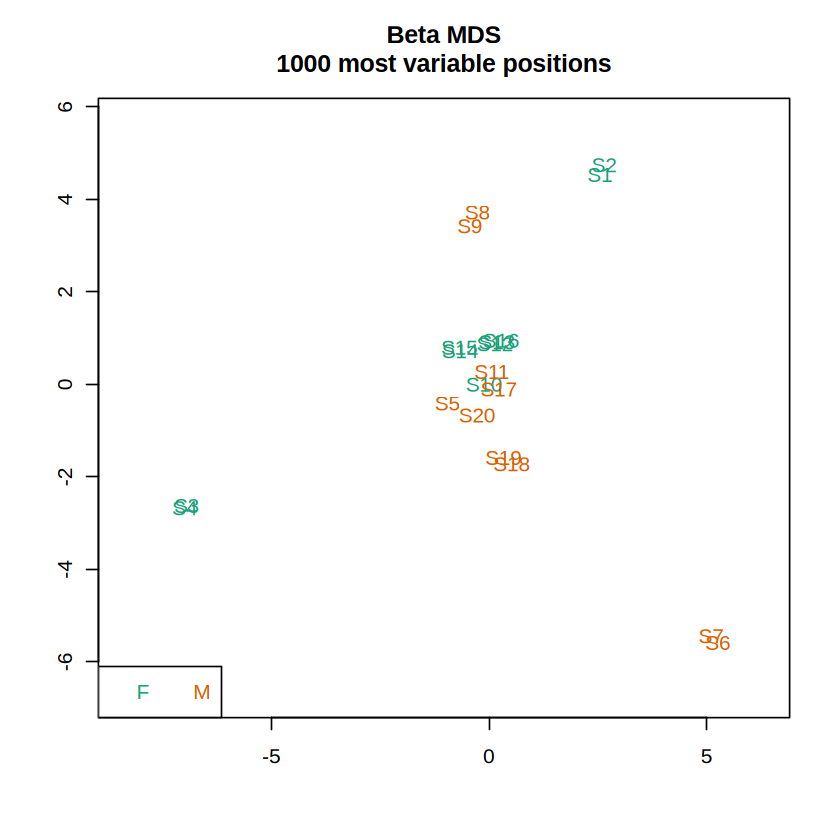

<< Plot densityPlot Done. >>


< Dendrogram Plot Feature Selection Method >: No Selection, directly use all CpGs to calculate distance matrix.



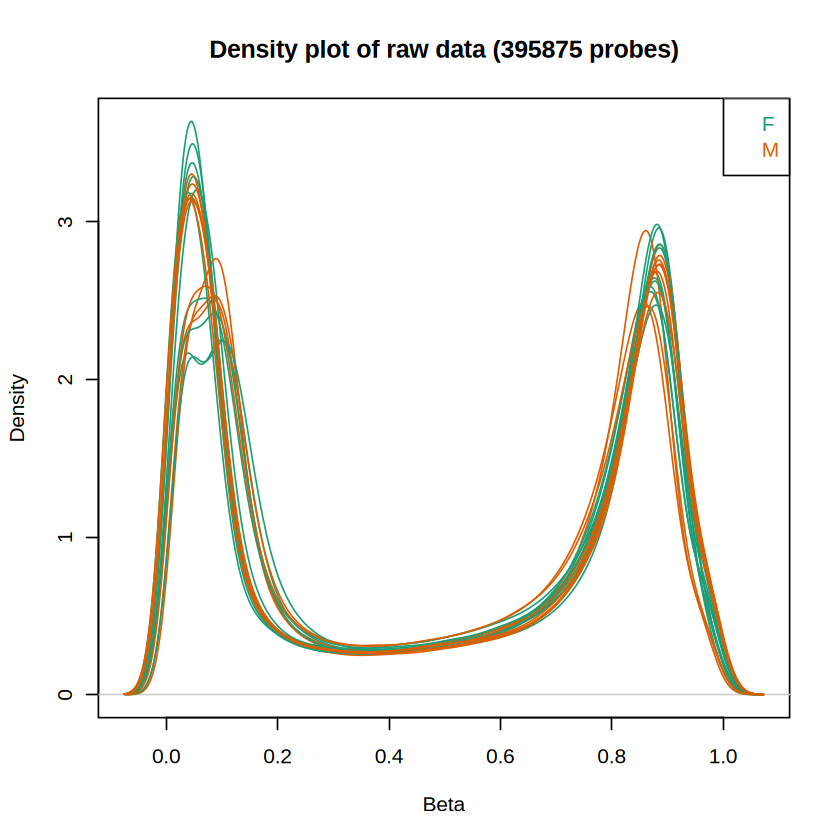

<< Plot dendrogram Done. >>


[<<<<<< ChAMP.QC END >>>>>>>]

[===========================]

[You may want to process champ.norm() next.]




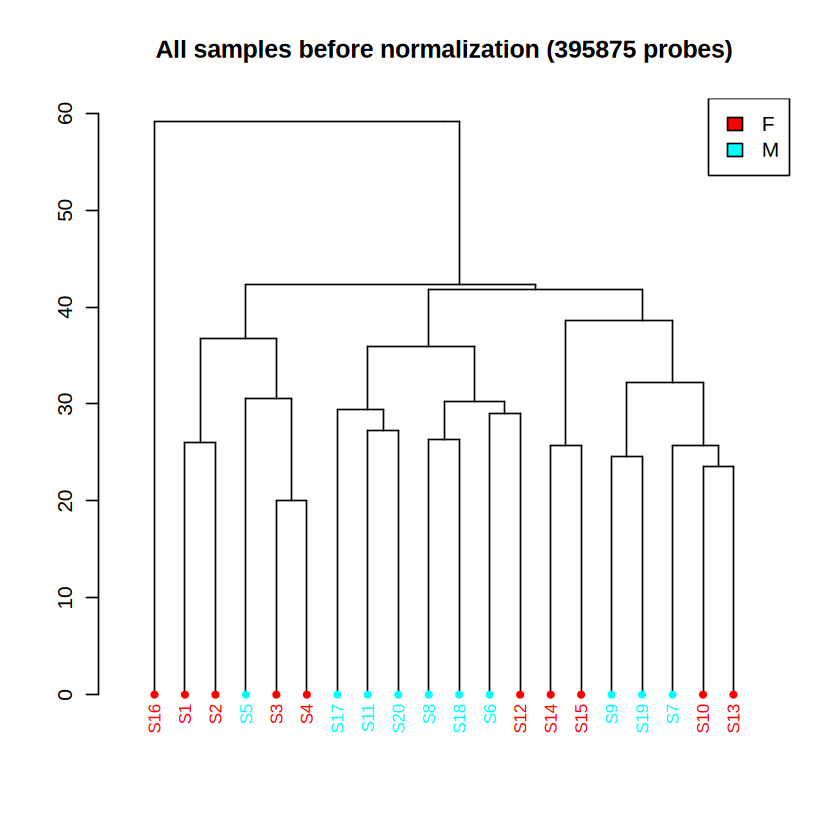

In [3]:
# Load in the data
myLoad <- champ.load(directory = data_dir,
                     method="ChAMP", # replaces old loading method using minfi
                     methValue="B", # wether to calculate beta- or M-values
                     autoimpute=TRUE, # if values are missing uses the 3 most similar probes and uses the mean of their values for the missing value 
                     filterDetP=TRUE, # filter single probes, whose methylation signal vs the background signal of the slide is not significant (detPcut)
                     ProbeCutoff=0, # remove all probes with higher missing-value-ratio
                     SampleCutoff=0.1, # remove a full sample if the failed probe ratio (based on p value) is higher
                     detPcut=0.01, # significance p-value cutoff for filterDetP
                     filterBeads=TRUE, # filter out probes if the fraction of samples with a beadcount < 3 is higher than beadCutoff
                     beadCutoff=0.05, # acceptable fraction of samples with a beadcount < 3
                     filterNoCG=TRUE, # wether to remove non-cg probes
                     filterSNPs=TRUE, # wether to remove probes that fallnear a SNP (as defined in Nordlund et al. https://link.springer.com/article/10.1186/s13059-021-02529-2) 
                     population=NULL, # can be assigned to specific population according to www.internationalgenome.org/category/population/
                     filterMultiHit=TRUE, # wether to remove probes that align to multiple genomic locations (also according to Nordlund et al.)
                     filterXY=TRUE, # wether to remove probes on x and y chromosomes
                     force=FALSE, # minfi specific parameter
                     arraytype="450K") # microarray type (can be one of "450K" "EPICv1" or "EPICv2") 

champ.QC(beta = myLoad$beta, # beta values stored in champ.load output
         pheno=myLoad$pd$Sample_Group, # what samplesheet column is your phenotype (where do u expect the major difference between your samples)?
         resultsDir="./CHAMP_QCimages/") # the plots will be saved in the directory this notebook file is located in


In [4]:
# for two of the normalization methods we need special input, which we generate below
targets <- read.metharray.sheet(data_dir)
rgset <- read.metharray.exp(targets = targets, recursive = TRUE)
mset <- preprocessRaw(rgset)
print("Generation of rgset and mset successfully")

[read.metharray.sheet] Found the following CSV files:



[1] "/home/jovyan/datasets/Jaffe/Samplesheet_m_f.csv"


Loading required package: IlluminaHumanMethylation450kmanifest



[1] "Generation of rgset and mset successfully"


#### Peak-based correction normalization (PBC)

[===========================]

[>>>>> ChAMP.NORM START <<<<<<]

-----------------------------

champ.norm Results will be saved in ./CHAMP_Normalization/

[ SWAN method call for BOTH rgSet and mset input, FunctionalNormalization call for rgset only , while PBC and BMIQ only needs beta value. Please set parameter correctly. ]


<< Normalizing data with PBC Method >>



[1] "Done for sample 1"
[1] "Done for sample 2"
[1] "Done for sample 3"
[1] "Done for sample 4"
[1] "Done for sample 5"
[1] "Done for sample 6"
[1] "Done for sample 7"
[1] "Done for sample 8"
[1] "Done for sample 9"
[1] "Done for sample 10"
[1] "Done for sample 11"
[1] "Done for sample 12"
[1] "Done for sample 13"
[1] "Done for sample 14"
[1] "Done for sample 15"
[1] "Done for sample 16"
[1] "Done for sample 17"
[1] "Done for sample 18"
[1] "Done for sample 19"
[1] "Done for sample 20"


[>>>>> ChAMP.NORM END <<<<<<]

[===========================]

[You may want to process champ.SVD() next.]


[===========================]

[<<<<< ChAMP.QC START >>>>>>]

-----------------------------

champ.QC Results will be saved in ./CHAMP_QCimages/PBC/

[QC plots will be proceed with 395875 probes and 20 samples.]


<< Prepare Data Over. >>

<< plot mdsPlot Done. >>




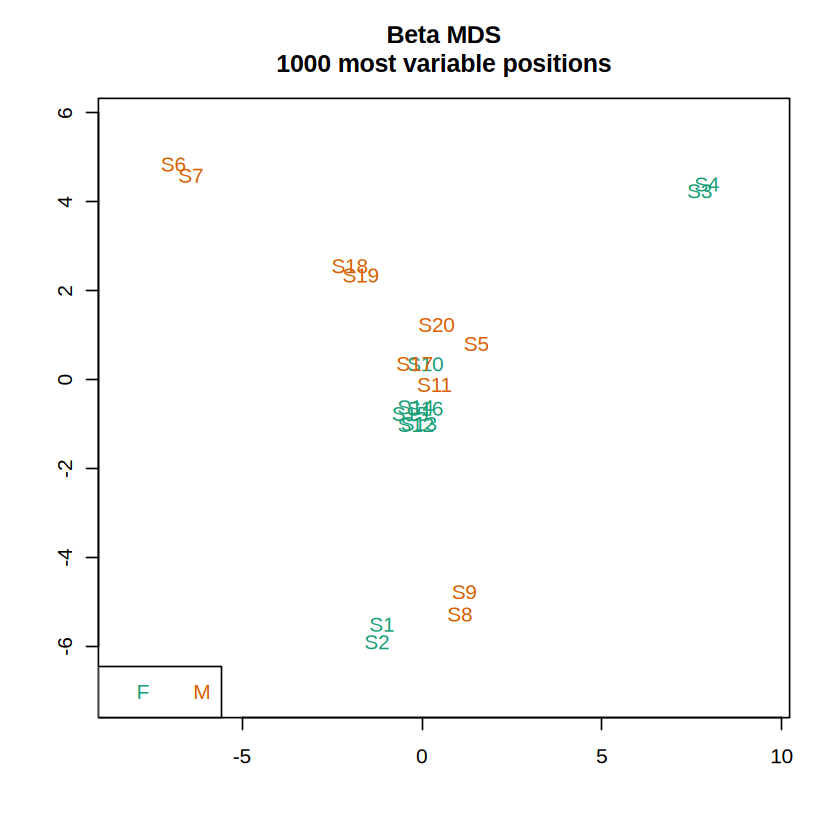

<< Plot densityPlot Done. >>


< Dendrogram Plot Feature Selection Method >: No Selection, directly use all CpGs to calculate distance matrix.



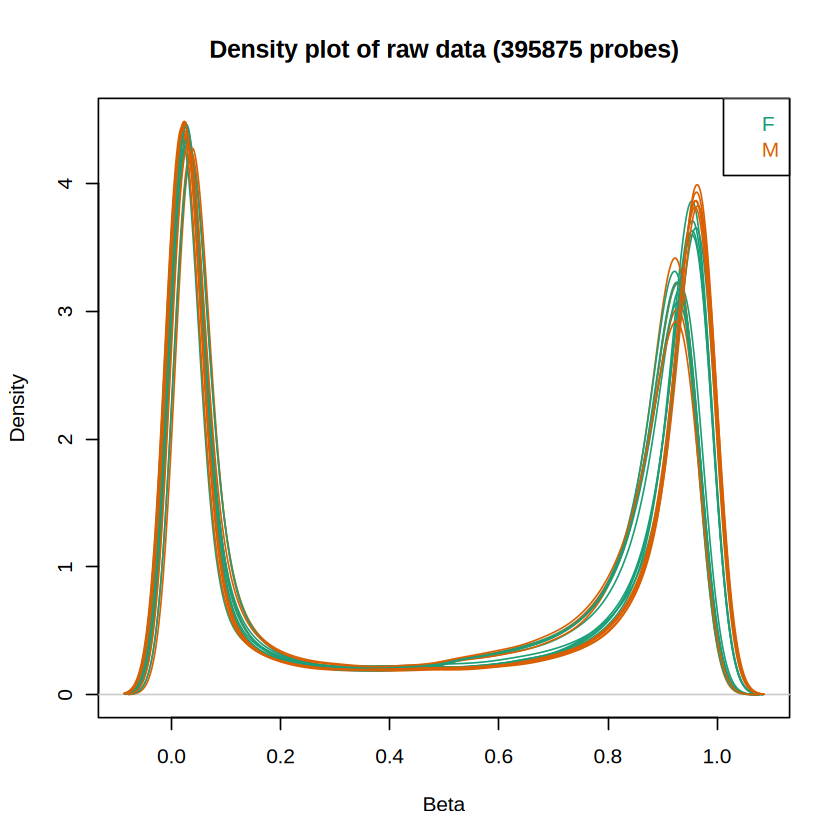

<< Plot dendrogram Done. >>


[<<<<<< ChAMP.QC END >>>>>>>]

[===========================]

[You may want to process champ.norm() next.]




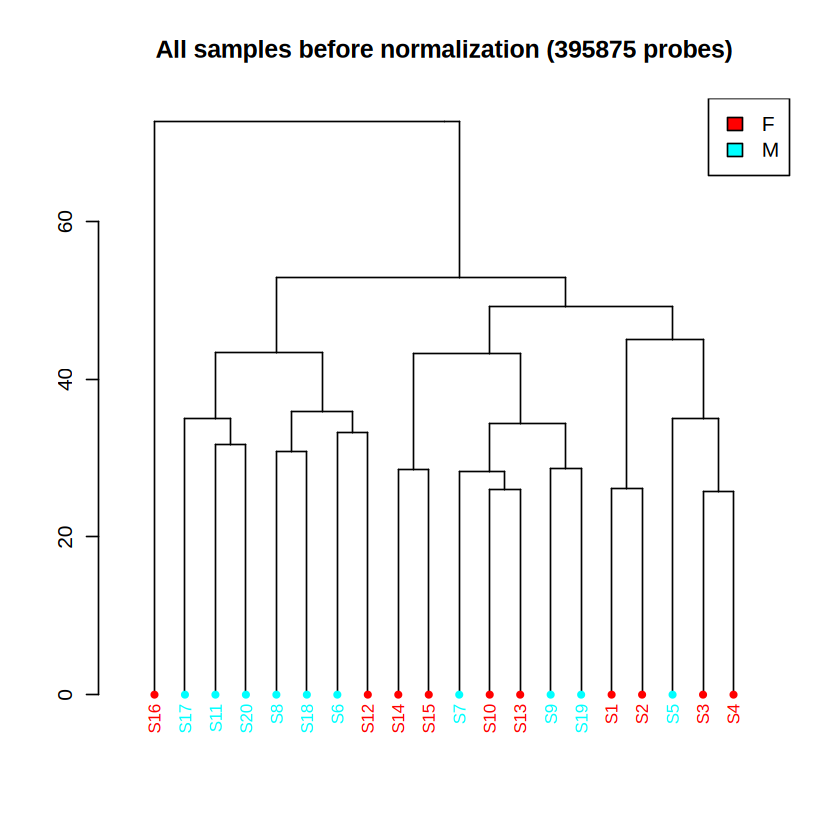

In [5]:
# start with PBC normalization
myNormPBC <- champ.norm(beta = myLoad$beta, arraytype = "450K", method = "PBC")
champ.QC(beta = myNormPBC, pheno = myLoad$pd$Sample_Group, resultsDir = "./CHAMP_QCimages/PBC/")

#### Beta-mixture quantile normalization (BMIQ)

[===========================]

[>>>>> ChAMP.NORM START <<<<<<]

-----------------------------

champ.norm Results will be saved in ./CHAMP_Normalization/

[ SWAN method call for BOTH rgSet and mset input, FunctionalNormalization call for rgset only , while PBC and BMIQ only needs beta value. Please set parameter correctly. ]


<< Normalizing data with BMIQ Method >>

Note that,BMIQ function may fail for bad quality samples (Samples did not even show beta distribution).

3 cores will be used to do parallel BMIQ computing.

[>>>>> ChAMP.NORM END <<<<<<]

[===========================]

[You may want to process champ.SVD() next.]


[===========================]

[<<<<< ChAMP.QC START >>>>>>]

-----------------------------

champ.QC Results will be saved in ./CHAMP_QCimages/BMIQ/

[QC plots will be proceed with 395875 probes and 20 samples.]


<< Prepare Data Over. >>

<< plot mdsPlot Done. >>




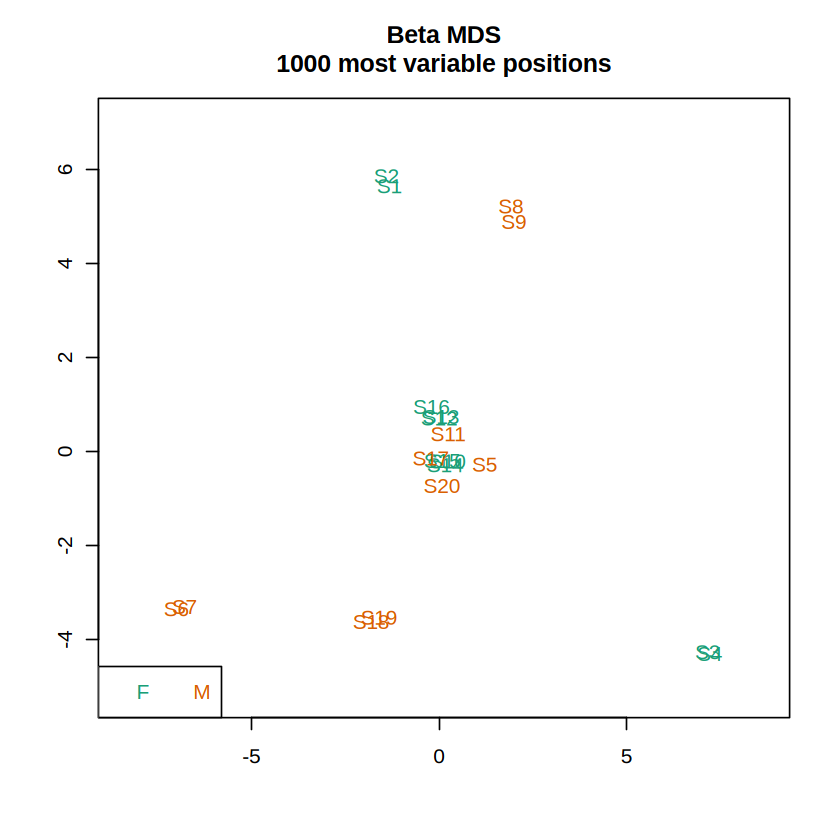

<< Plot densityPlot Done. >>


< Dendrogram Plot Feature Selection Method >: No Selection, directly use all CpGs to calculate distance matrix.



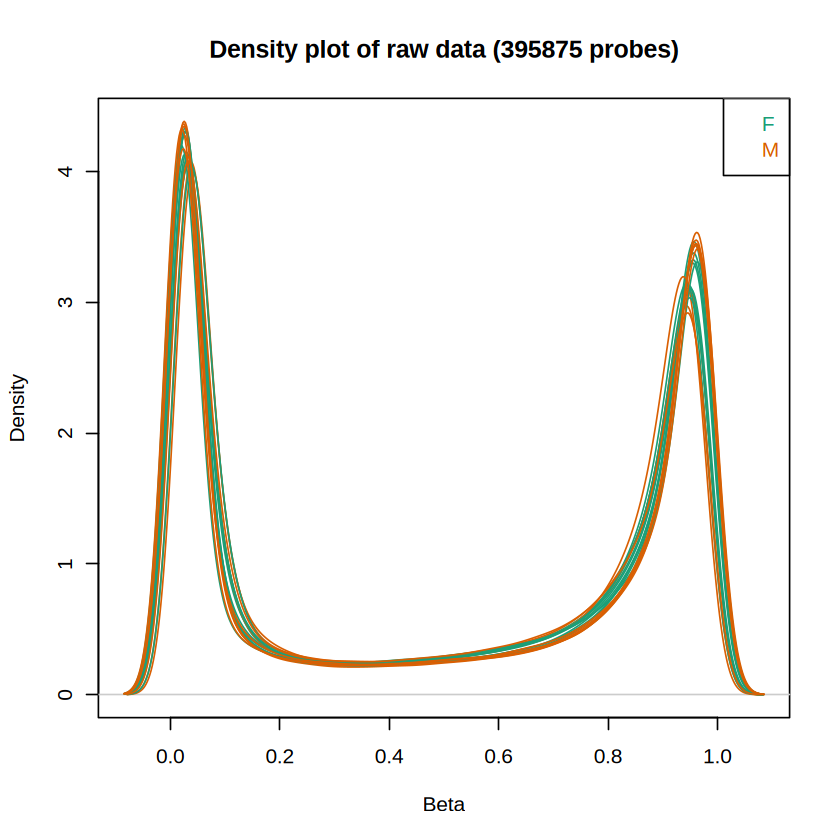

<< Plot dendrogram Done. >>


[<<<<<< ChAMP.QC END >>>>>>>]

[===========================]

[You may want to process champ.norm() next.]




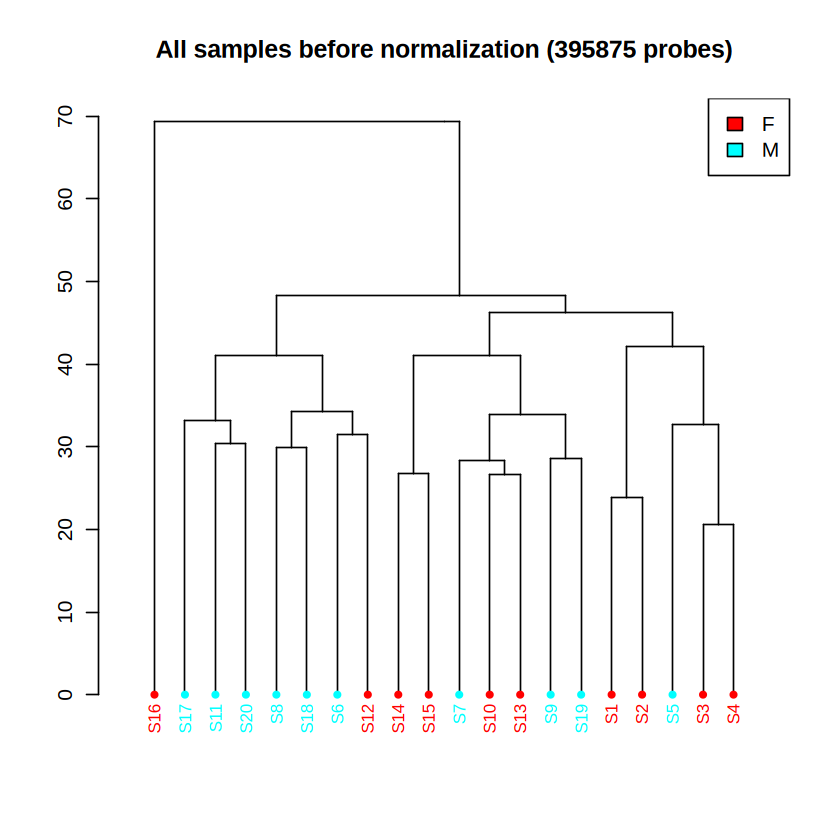

In [6]:
# BMIQ normalization
myNormBMIQ <- champ.norm(beta = myLoad$beta, arraytype = "450K", method = "BMIQ")
champ.QC(beta = myNormBMIQ, pheno=myLoad$pd$Sample_Group, resultsDir="./CHAMP_QCimages/BMIQ/")

#### Functional Normalization (FunNorm)

[===========================]

[>>>>> ChAMP.NORM START <<<<<<]

-----------------------------

champ.norm Results will be saved in ./CHAMP_Normalization/

[ SWAN method call for BOTH rgSet and mset input, FunctionalNormalization call for rgset only , while PBC and BMIQ only needs beta value. Please set parameter correctly. ]


[preprocessFunnorm] Background and dye bias correction with noob

[preprocessFunnorm] Mapping to genome

[preprocessFunnorm] Quantile extraction

[preprocessFunnorm] Normalization

[>>>>> ChAMP.NORM END <<<<<<]

[===========================]

[You may want to process champ.SVD() next.]


[===========================]

[<<<<< ChAMP.QC START >>>>>>]

-----------------------------

champ.QC Results will be saved in ./CHAMP_QCimages/FunNorm/

[QC plots will be proceed with 395875 probes and 20 samples.]


<< Prepare Data Over. >>

<< plot mdsPlot Done. >>




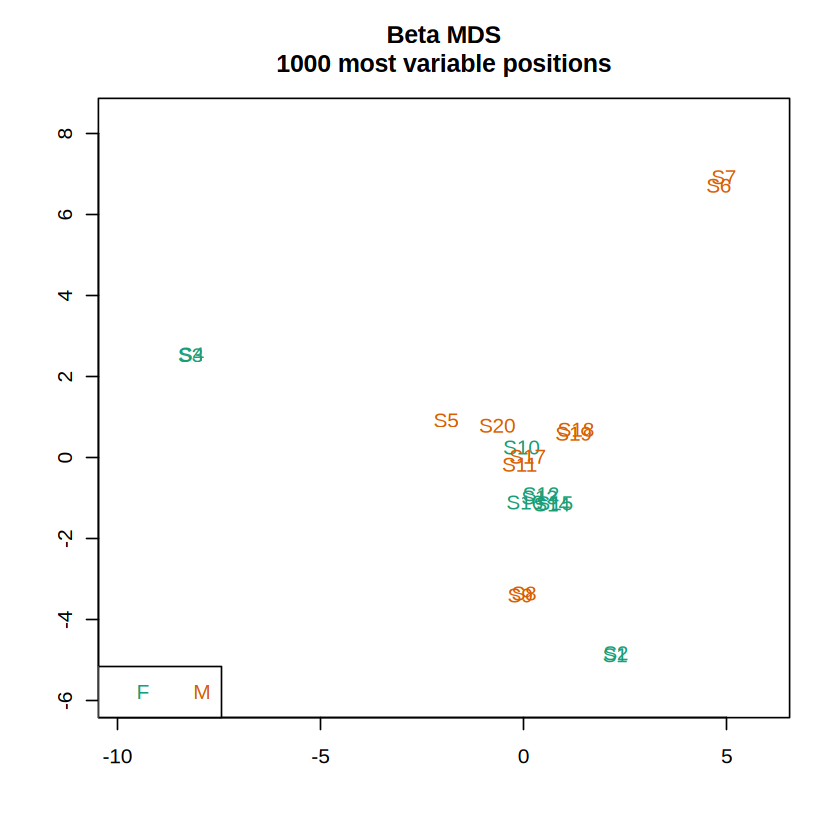

<< Plot densityPlot Done. >>


< Dendrogram Plot Feature Selection Method >: No Selection, directly use all CpGs to calculate distance matrix.



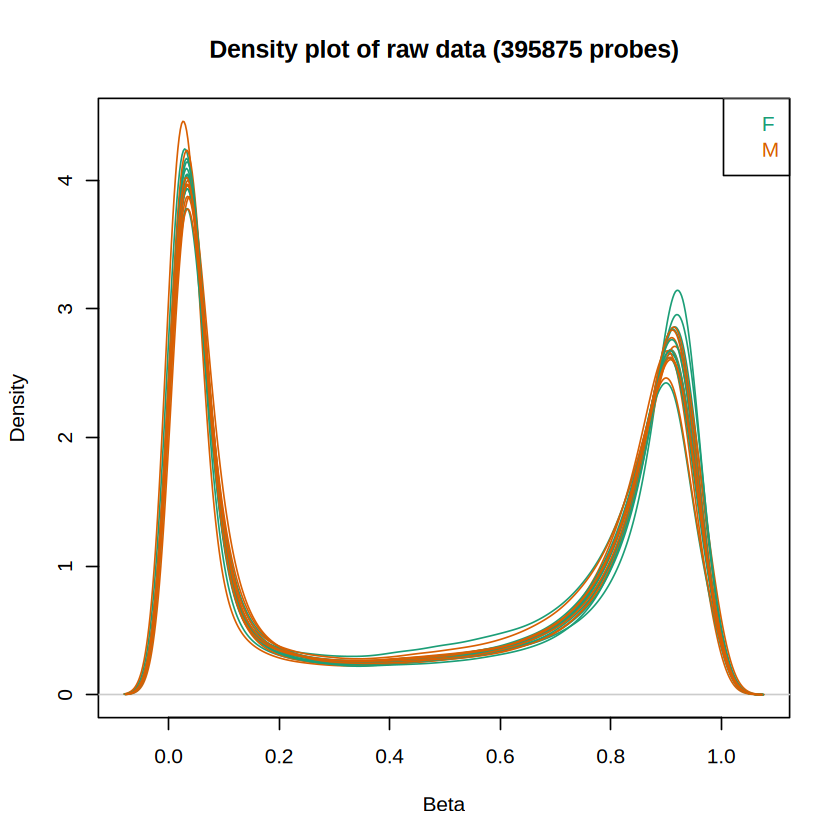

<< Plot dendrogram Done. >>


[<<<<<< ChAMP.QC END >>>>>>>]

[===========================]

[You may want to process champ.norm() next.]




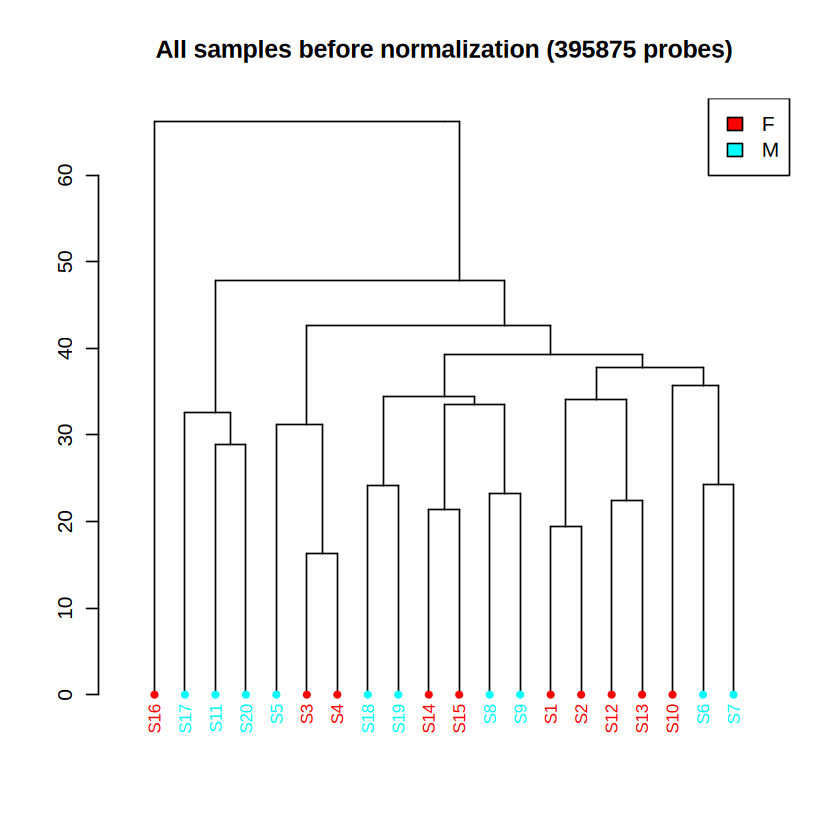

In [7]:
myNormFunNorm <- champ.norm(beta = myLoad$beta, arraytype = "450K", method = "FunctionalNormalization", rgSet = rgset)
champ.QC(beta = myNormFunNorm, pheno = myLoad$pd$Sample_Group, resultsDir = "./CHAMP_QCimages/FunNorm/")

In [8]:
# save best looking normalization result
myNorm <- myNormBMIQ

#### Generate a SVD plot that highlights significant differences between groups of samples (Significant differences in the group of interest are good)

[===========================]

[<<<<< ChAMP.SVD START >>>>>]

-----------------------------

champ.SVD Results will be saved in ./CHAMP_SVDimages/ .


[SVD analysis will be proceed with 395875 probes and 20 samples.]



[ champ.SVD() will only check the dimensions between data and pd, instead if checking if Sample_Names are correctly matched (because some user may have no Sample_Names in their pd file),thus please make sure your pd file is in accord with your data sets (beta) and (rgSet).]


<< Following Factors in your pd(sample_sheet.csv) will be analysised: >>

<Sample_ID>(character):GSM1913625, GSM1913626, GSM1913627, GSM1913628, GSM1913629, GSM1913631, GSM1913632, GSM1913633, GSM1913634, GSM1913635, GSM1913637, GSM1913639, GSM1913640, GSM1913641, GSM1913642, GSM1913644, GSM1913645, GSM1913655, GSM1913656, GSM1913657

<Slide>(character):GSM1913625_5815188028, GSM1913626_6229009146, GSM1913627_5806484002, GSM1913628_6229009147, GSM1913629_5806484010, GSM1913631_6229009145, GSM191363

Sample_ID,Slide,Array,Sample_Group
0.4568361,0.4568361,0.2882561,0.76236882
0.4568361,0.4568361,0.3403492,0.11241058
0.4568361,0.4568361,0.4186372,0.36434613
0.4568361,0.4568361,0.7231953,0.82059584
0.4568361,0.4568361,0.1745175,0.25683926
0.4568361,0.4568361,0.8550156,0.02836551
0.4568361,0.4568361,0.5343647,0.03429372
0.4568361,0.4568361,0.1277815,0.59670122


[===========================]

[<<<<< ChAMP.SVD START >>>>>]

-----------------------------

champ.SVD Results will be saved in ./CHAMP_SVDimages/ .


[SVD analysis will be proceed with 395875 probes and 20 samples.]



[ champ.SVD() will only check the dimensions between data and pd, instead if checking if Sample_Names are correctly matched (because some user may have no Sample_Names in their pd file),thus please make sure your pd file is in accord with your data sets (beta) and (rgSet).]


<< Following Factors in your pd(sample_sheet.csv) will be analysised: >>

<Sample_ID>(character):GSM1913625, GSM1913626, GSM1913627, GSM1913628, GSM1913629, GSM1913631, GSM1913632, GSM1913633, GSM1913634, GSM1913635, GSM1913637, GSM1913639, GSM1913640, GSM1913641, GSM1913642, GSM1913644, GSM1913645, GSM1913655, GSM1913656, GSM1913657

<Slide>(character):GSM1913625_5815188028, GSM1913626_6229009146, GSM1913627_5806484002, GSM1913628_6229009147, GSM1913629_5806484010, GSM1913631_6229009145, GSM191363

Sample_ID,Slide,Array,Sample_Group
0.4568361,0.4568361,0.2882561,0.76236882
0.4568361,0.4568361,0.3403492,0.11241058
0.4568361,0.4568361,0.4186372,0.36434613
0.4568361,0.4568361,0.7231953,0.82059584
0.4568361,0.4568361,0.1745175,0.25683926
0.4568361,0.4568361,0.8550156,0.02836551
0.4568361,0.4568361,0.5343647,0.03429372
0.4568361,0.4568361,0.1277815,0.59670122


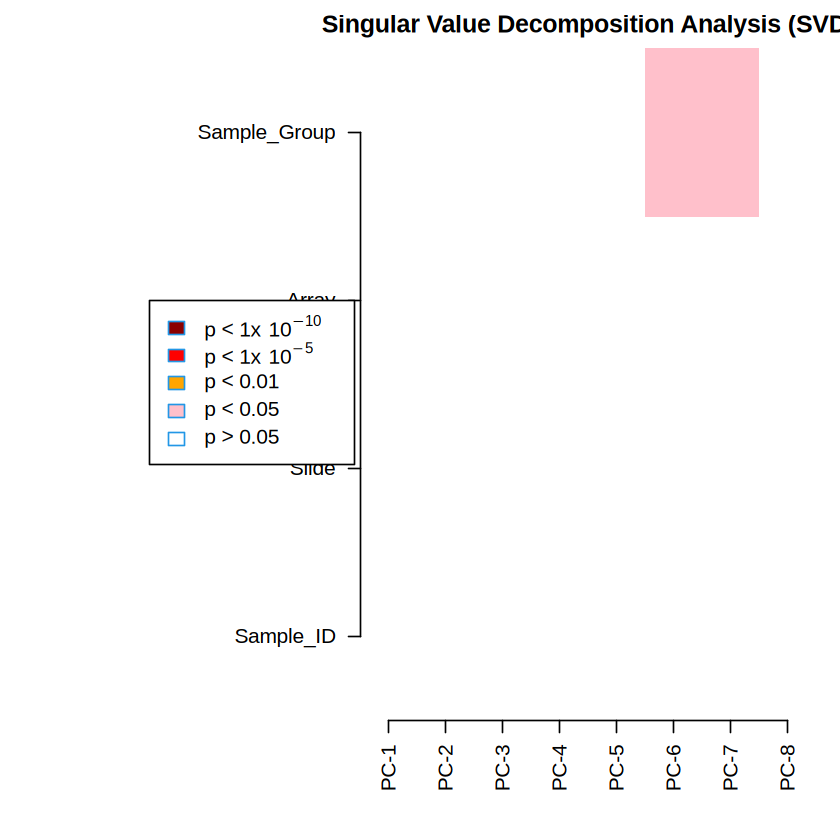

In [9]:
champ.SVD(beta=myNorm, pd=myLoad$pd, resultsDir="./CHAMP_SVDimages/")
SVD_custom(beta=myNorm, filename = "SVD_Jaffe.pdf")

#### Calculate Differentially Methylated Probes (DMPs) between Samplegroups

In [10]:
DMPs <- champ.DMP(beta = myNorm,pheno=myLoad$pd$Sample_Group, adjPVal = 0.05, arraytype = "450K")
saveRDS(DMPs, file = "/home/jovyan/myDMP.rds")
saveRDS(myNorm, file = "/home/jovyan/myNorm.rds")
saveRDS(myLoad, file = "/home/jovyan/myLoad.rds")
print("DMP detection completed")

[===========================]

[<<<<< ChAMP.DMP START >>>>>]

-----------------------------

!!! Important !!! New Modification has been made on champ.DMP(): 


    (1): In this version champ.DMP() if your pheno parameter contains more than two groups of phenotypes, champ.DMP() would do pairewise differential methylated analysis between each pair of them. But you can also specify compare.group to only do comparasion between any two of them.


    (2): champ.DMP() now support numeric as pheno, and will do linear regression on them. So covariates like age could be inputted in this function. You need to make sure your inputted "pheno" parameter is "numeric" type.


--------------------------------


[ Section 1:  Check Input Pheno Start ]


  You pheno is character type.

    Your pheno information contains following groups. >>

    <F>:10 samples.

    <M>:10 samples.

    [The power of statistics analysis on groups contain very few samples may not strong.]

    pheno contains only 2 phe

      Contrasts
Levels pM-pF
    pF    -1
    pM     1


  You have found 61 significant MVPs with a BH adjusted P-value below 0.05.

  Calculate DMP for F and M done.


[ Section 2:  Find Numeric Vector Related CpGs Done ]



[ Section 3:  Match Annotation Start ]



[ Section 3:  Match Annotation Done ]


[<<<<<< ChAMP.DMP END >>>>>>]

[===========================]

[You may want to process DMP.GUI() or champ.GSEA() next.]




[1] "DMP detection completed"


#### Visualize and explore the calculated DMPs

In [11]:
urls <- paste0("https://methylomemasterclass202609.jhaas.gi.denbi.de/user/", Sys.getenv("JUPYTERHUB_USER"), "/shiny/notebooks/App/DMP.GUI/")
cli::cli_text("Click here for interactive exploration of DMPs: {urls}.")

Click here for interactive exploration of DMPs:
https://methylomemasterclass202609.jhaas.gi.denbi.de/user/9e112b87-20f5-4aec-869e-4dfb60de4beb/shiny/notebooks/App/DMP.GUI/.



#### Calculate Differentially Methylated Regions (DMRs) between Samplegroups

In [12]:
DMRs <- champ.DMR(beta=myNorm,pheno=myLoad$pd$Sample_Group,method="Bumphunter", arraytype="450K", cores=2)
saveRDS(DMRs, "/home/jovyan/myDMR.rds")
print("DMR detection completed")

[===========================]

[<<<<< ChAMP.DMR START >>>>>]

-----------------------------

!!! important !!! We just upgrate champ.DMR() function, since now champ.DMP() could works on multiple phenotypes, but ProbeLasso can only works on one DMP result, so if your pheno parameter contains more than 2 phenotypes, and you want to use ProbeLasso function, you MUST specify compare.group=c("A","B"). Bumphunter and DMRcate should not be influenced.


[ Section 1:  Check Input Pheno Start ]


  You pheno is character type.

    Your pheno information contains following groups. >>

    <F>:10 samples.

    <M>:10 samples.


[ Section 1:  Check Input Pheno Done ]



[ Section 2:  Run DMR Algorithm Start ]


<< Find DMR with Bumphunter Method >>

2 cores will be used to do parallel Bumphunter computing.

According to your data set, champ.DMR() detected 7101 clusters contains MORE THAN 7 probes within 300 maxGap. These clusters will be used to find DMR.


[bumphunterEngine] Parallelizing using 

[1] "DMR detection completed"


#### Visualize and explore the calculated DMRs

In [23]:
urls <- paste0("https://methylomemasterclass202609.jhaas.gi.denbi.de/user/", Sys.getenv("JUPYTERHUB_USER"), "/shiny/notebooks/App/DMR.GUI450K/")
cli::cli_text("Click here for interactive exploration of DMRs: {urls}.")

Click here for interactive exploration of DMRs:
https://methylomemasterclass202609.jhaas.gi.denbi.de/user/9e112b87-20f5-4aec-869e-4dfb60de4beb/shiny/notebooks/App/DMR.GUI450K/.



#### Filter the calculated DMRs for significance

In [27]:
anno <- getAnnotation(IlluminaHumanMethylation450kanno.ilmn12.hg19)

DMRs_filt <- filter_dmrs(DMRs$BumphunterDMR, pval = 0.05, fwer = 0.2,min_abs_value = 0.5)
DMRs_anno <- annotateDMRs(DMRs_filt, anno = anno, myNorm = myNorm)
DMRs_head <- DMRs_anno[1:min(c(nrow(DMRs_anno), 10)), ]
print(DMRs_head)
DMRs_tail <- DMRs_anno[max(c(0,(nrow(DMRs_anno)-9))):nrow(DMRs_anno), ]

DMR 1 annotiert: 10 CpGs gefunden.
DMR 2 annotiert: 6 CpGs gefunden.
      seqnames    start      end width strand    value      area cluster
DMR_2    chr21 45705429 45706101   672      * 1.241947 12.419471  129819
DMR_1     chr6 30122388 30122593   205      * 1.518682  9.112092  169565
      indexStart indexEnd  L clusterL      p.value  fwer p.valueArea fwerArea
DMR_2      48638    48647 10       12 0.0004972474 0.116 0.002509915    0.464
DMR_1      63858    63863  6       15 0.0002131060 0.048 0.007837566    0.728
      n_CpGs
DMR_2     10
DMR_1      6
                                                                                                               CpGs
DMR_2 cg08089567;cg09510531;cg11923631;cg16717549;cg18689454;cg23272544;cg27251412;cg12843033;cg17356252;cg18876487
DMR_1                                             cg02638136;cg07873154;cg08094206;cg11857238;cg15979214;cg24847621
       Genes               RefGene_Group
DMR_2   AIRE 1stExon;TSS200;TSS1500;Body
DMR_1 TRI

#### Plot heatmaps for the filtered DMRs
You can use this section in combination with the DMR or DMP GUIs to visualize methylation across samples for genes of interest.

In [26]:
makeHeatmap_genelist(pdfname = "./Heatmap_images/heatmap_Cortez_Cardoso_genelist.pdf",
                            anno = anno,
                            genelist = c("NPY", "RASSF1", "CLDN10"), # Here you can add gene names of genes that you saw in DMPs/DMRs to see their overall methylation pattern
                                                                     # and find potentially interesting targets for your poster
                            myNorm = myNorm,
                            targets = targets,
                            pd_col = "Sample_Group",
                            compare_values = c("F", "M"))

makeHeatmap_dmr(pdfname = "./Heatmap_images/heatmap_Cortez_Cardoso_dmrs_hypermethylated.pdf",
                dmrs = DMRs_head,
                anno = anno,
                myNorm = myNorm,
                targets = targets,
                pd_col = "Sample_Group",
                compare_values = c("F", "M"))

makeHeatmap_dmr(pdfname = "./Heatmap_images/heatmap_Cortez_Cardoso_dmrs_hypomethylated.pdf",
                dmrs = DMRs_tail,
                anno = anno,
                myNorm = myNorm,
                targets = targets,
                pd_col = "Sample_Group",
                compare_values = c("F", "M"))

Starte Heatmap für NPY 


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'β-Wert' in 'mbcsToSbcs': for β (U+03B2)"


Starte Heatmap für RASSF1 


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'β-Wert' in 'mbcsToSbcs': for β (U+03B2)"


Starte Heatmap für CLDN10 


...

Starte Heatmap für DMR 1 


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'β-Wert' in 'mbcsToSbcs': for β (U+03B2)"


Starte Heatmap für DMR 2 


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'β-Wert' in 'mbcsToSbcs': for β (U+03B2)"


agg_record_2099746914 
                    2